# Global sea level change time series from 1950 to 2050 derived from reanalysis and high resolution CMIP6 climate projections

Production date: YYYY-MM-DD

**Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch.**

Produced by: C3S2_521 contract.

## 🌍 Use case: Use case listed here in full 

## ❓ Quality assessment question
* **In most cases there should be one question listed here in bold**
* **(In some cases a second related/follow-up question may be included)**

**‘Context paragraph’ (no title/heading)** - a very short introduction before the assessment statement describing approach taken to answer the user question. One or two key references could be useful, if the assessment summarises literature.

**Background**
Check documentation: Only one model? Mean?

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* Finding 1
* Finding 2
* Finding 3
* etc
```

## 📋 Methodology

A ‘free text’ introduction to the data analysis steps or a description of the literature synthesis, with a justification of the approach taken, and limitations mentioned. **Mention which CDS catalogue entry is used, including a link, and also any other entries used for the assessment**.
[Global sea level change time series from 1950 to 2050 derived from reanalysis and high resolution CMIP6 climate projections](https://doi.org/10.24381/cds.a6d42d60)

**Note:** This notebook is currently just a brain-dump in anticipation of starting the actual quality assessment at a later stage.

E.g. 'The analysis and results are organised in the following steps, which are detailed in the sections below:' 

**[](section-setup)**
 * Sub-steps or key points listed in bullet below. No strict requirement to match and link to sub-headings.

**[](section-analysis)**
 * Sub-steps or key points listed in bullet below. No strict requirement to match and link to sub-headings.

**[](section-results)**
 * Sub-steps or key points listed in bullet below. No strict requirement to match and link to sub-headings.

Any further notes on the method could go here (explanations, caveats or limitations).

## 📈 Analysis and results

(section-setup)=
### 1. Code setup

#### Imports

In [1]:
# Input / Output
from pathlib import Path
import earthkit.data as ekd
import warnings

# General data handling
import numpy as np
np.seterr(divide="ignore")  # Ignore divide-by-zero warnings
import pandas as pd
import xarray as xr
from functools import partial
from dask.array.core import PerformanceWarning
warnings.simplefilter(action="ignore", category=PerformanceWarning)
from itertools import batched

# Visualisation
import earthkit.plots as ekp
from earthkit.plots.styles import Style
import matplotlib.pyplot as plt
plt.rcParams["grid.linestyle"] = "--"
from matplotlib.colors import LogNorm
import cmcrameri as cmc
from tqdm import tqdm  # Progress bars

# Visualisation in Jupyter book -- automatically ignored otherwise
try:
    from myst_nb import glue
except ImportError:
    glue = None

#### Helper functions

##### General

In [2]:
# Type hints for helper functions
from typing import Callable, Optional, Iterable

# For pre-defining functions
from functools import partial

##### Downloading data

In [3]:
## Data downloading
def domain_to_request(domain: ekp.geo.domains.Domain) -> dict:
    """ From an earthkit-plots domain, generate a request for earthkit-data / cdsapi. """
    bbox = domain.bbox.to_latlon_bbox()

    # Round
    north = int(np.ceil(bbox.north) + 1)
    south = int(np.floor(bbox.south) - 1)
    west = int(np.floor(bbox.west) - 1)
    east = int(np.ceil(bbox.east) + 1)
    
    area = [north, west, south, east]
    return {"area": area}

# Handling CDS size limits
def batch_requests(main_request: dict, *, batch_key: str="year", n: int=20) -> list[dict]:
    """ Take a big request (e.g. ERA5–Drought for all years) and separate it into smaller ones (size `n`). """
    full_range = main_request[batch_key]  # e.g. [1940, 1941, ..., 2024]
    batched_range = batched(full_range, n)  # e.g. [1940, ..., 1959], [1960, ..., 1979], ...
    subrequests = [main_request | {batch_key: batch} for batch in batched_range]  # create corresponding CDS requests
    return subrequests

##### Data (pre-)processing

In [4]:
## Loops for convenience
def loop_over_(*args, progress=True, **kwargs) -> tqdm:
    """ Generate a tqdm progressbar; inverts `disable` keyword """
    return tqdm(*args, disable=not progress, leave=False, **kwargs)

def loop_over_ensemble_members(data: xr.Dataset, **tqdm_kwargs) -> tqdm:
    """ Loop over ensemble members in `data`, with a progress bar. """
    return loop_over_(data.groupby("number"), unit="member", **tqdm_kwargs)

def loop_over_data_variables(data: xr.Dataset, **tqdm_kwargs) -> tqdm:
    """ Loop over variable keys in `data`, with a progress bar. """
    return loop_over_(data.data_vars.keys(), unit="variable", **tqdm_kwargs)

##### Visualisation

In [5]:
_style_chl = {"cmap": cmc.cm.navia.resampled(15), "norm": LogNorm(vmin=1e-6, vmax=50), "extend": "both"}

styles = {
    "chl": Style(**_style_chl),
}

# Apply general settings
for style in styles.values():
    style.normalize = False

In [6]:
def _add_textbox_to_subplots(text: str, *axs: Iterable[plt.Axes | ekp.Subplot], right=False) -> None:
    """ Add a text box to each of the specified subplots. """
    # Get the plt.Axes for each ekp.Subplot
    axs = [subplot.ax if isinstance(subplot, ekp.Subplot) else subplot for subplot in axs]

    # Set up location
    x = 0.95 if right else 0.05
    horizontalalignment = "right" if right else "left"

    # Add the text
    for ax in axs:
        ax.text(x, 0.95, text, transform=ax.transAxes,
        horizontalalignment=horizontalalignment, verticalalignment="top",
        bbox={"facecolor": "white", "edgecolor": "black", "boxstyle": "round",
              "alpha": 1})

In [7]:
def decorate_fig(fig: ekp.Figure, *, title: Optional[str]="") -> None:
    """ Decorate an earthkit figure with land, coastlines, etc. """
    # Add progress bar because individual steps can be very slow for large plots
    with tqdm(total=4, desc="Decorating", leave=False) as progressbar:
        fig.land()
        progressbar.update()
        fig.coastlines()
        progressbar.update()
        # fig.borders()
        # progressbar.update()
        fig.gridlines(linestyle=plt.rcParams["grid.linestyle"])
        progressbar.update()
        fig.title(title)
        progressbar.update()

(section-analysis)=
### 2. Download Timeseries Dataset

In [23]:
# Setup
DATASET_ID = "sis-water-level-change-timeseries-cmip6"
YEARS = (1985, 2014) # download present epoch

#### Reanalysis - Present Epoch (1985-2014)

In [9]:
request_reanalysis = {
    "variable": [
        "storm_surge_residual",
    ],
    "experiment": "reanalysis",
    "temporal_aggregation": ["10_min"],
    "year": [f"{year}" for year in range(YEARS[0], YEARS[1]+1)],    
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "version": ["v3"]
}

In [11]:
# Download reanalysis data for present epoch in 1 year batches.
subrequests_reanalysis  = batch_requests(request_reanalysis, n= 1)

data_reanalysis = ekd.from_source("cds", DATASET_ID, *subrequests_reanalysis).to_xarray()

# Display result
data_reanalysis

  0%|          | 0/30 [00:00<?, ?it/s]

<xarray.Dataset> Size: 544GB
Dimensions:               (time: 1577808, stations: 43119)
Coordinates:
  * time                  (time) datetime64[ns] 13MB 1985-01-01 ... 2014-12-3...
  * stations              (stations) uint16 86kB 0 1 2 3 ... 43731 43732 43733
    station_x_coordinate  (stations) float64 345kB dask.array<chunksize=(43119,), meta=np.ndarray>
    station_y_coordinate  (stations) float64 345kB dask.array<chunksize=(43119,), meta=np.ndarray>
Data variables:
    surge                 (time, stations) float64 544GB dask.array<chunksize=(893, 8624), meta=np.ndarray>
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         10-minute timeseries of surge levels
    ...                            ...
    time_coverage_start:           1985-01-01 00:00:00
    time_coverage_end:             1985-01-31 23:50:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 13:31:31.692854 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       This is version 3 of the dataset.

#### Historical - Present Epoch (1985-2014)

In [28]:
request_historical = {
    "variable": [
        "storm_surge_residual",
    ],
    "experiment": "historical",
    "model": ["cmcc_cm2_vhr4"],
    "temporal_aggregation": ["10_min"],
    "year": [f"{year}" for year in range(YEARS[0], YEARS[1]+1)],    
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "version": ["v1"],
}

In [ ]:
# Download historical data
subrequests_historical  = batch_requests(request_historical, n= 1)

data_historical = ekd.from_source("cds", DATASET_ID, *subrequests_historical).to_xarray()

# Display result
data_historical

  0%|          | 0/30 [00:00<?, ?it/s]

2026-05-12 11:20:09,925 INFO [2025-04-17T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be updated to accommodate this change. Please see the known issues under the Documentation tab for more information regarding the version update.
2026-05-12 11:20:09,927 INFO Request ID is 490a7c26-c8bf-4153-8b67-b5f0eae3a0f0
2026-05-12 11:20:10,000 INFO status has been updated to accepted
2026-05-12 11:20:10,258 INFO [2025-04-17T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be updated to accommodate this change. Please see the known issues under the Documentation tab for more information regarding the version update.
2026-05-12 11:20:10,259 INFO Request ID is b1a070d1-8194-4f8d-87a0-066a3b2afea4
2026-05-12 11:20:10,264 INFO [2025-04-17T00:00:00] A new version has been added requiring a change to the download form. Users are advi

2e87b22e58b591524504d800c199de41.zip:   0%|          | 0.00/2.01G [00:00<?, ?B/s]

2026-05-12 11:22:09,320 INFO status has been updated to successful
2026-05-12 11:22:12,638 INFO status has been updated to successful


a6237dc323f6a4371e40ecee6d1329d3.zip:   0%|          | 0.00/2.01G [00:00<?, ?B/s]

...

4c23ba0e83566b0ba79ef28183c5a160.zip:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

2026-05-12 12:24:50,334 INFO status has been updated to running
2026-05-12 12:26:13,448 INFO status has been updated to successful


f649c20f9b8e0663b23ed769b20c823a.zip:   0%|          | 0.00/2.01G [00:00<?, ?B/s]

2026-05-12 12:44:08,825 INFO [2025-04-17T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be updated to accommodate this change. Please see the known issues under the Documentation tab for more information regarding the version update.
2026-05-12 12:44:08,826 INFO Request ID is 3789e613-8d71-4b74-b8e8-18a8643fb434
2026-05-12 12:44:10,646 INFO status has been updated to accepted
2026-05-12 12:44:26,808 INFO status has been updated to running
2026-05-12 12:46:08,938 INFO status has been updated to successful


dd37e5612b77e6a88d5924eadb70f84f.zip:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

#### 3. Calculating Return Periods - (one station - 95th Percentile)

In [ ]:
def decluster_surge(data, percentile = 95, station = 22222):

    station_data = data.sel(stations=station)
    time = station_data["time"].values
    surge = station_data["surge"].values

    pXX = np.nanquantile(surge, percentile/100) # find percentile
    pXX_idx = np.where(surge > pXX)[0] # find indices of all storm surge values greater than the threshold value

    min_run_length = np.timedelta64(1, "h") # in datetime format
    max_run_length = np.timedelta64(72, "h") # in datetime format
    
    dt = np.diff(time[pXX_idx]) # find difference in time for all values that exceed threshold
    new_cluster = np.insert(arr =  (dt > min_run_length) , obj =  0, values = True) # insert True in first cluster
    cluster_id = np.cumsum(new_cluster) # cluster all exceedances

    t_pXX = time[pXX_idx] # times that exceed 99 percentile threshold
    
    # find cluster start/end indices
    starts = np.where(new_cluster)[0]
    ends = np.append(starts[1:] - 1, len(t_pXX) - 1 ) # append list of start of next clusters + insert last one
    
    # cluster durations
    durations = (t_pXX[ends] - t_pXX[starts]) / (60*60*(10**9)) # convert nanoseconds to hours

    declustered_idx = []
    
    for s, e, d in zip(starts, ends, durations):
        if d <= 72: # max storm duration
            i = pXX_idx[s:e+1] # slice each cluster 
            declustered_idx.append(i[np.argmax(surge[i])]) # find maximum surge value index in each cluster
    
    declustered_surge = surge[declustered_idx] 

    return declustered_surge

declustered_surge = decluster_surge(data_reanalysis)
    

Text(0.5, 1.0, 'Histogram of declustered surge extremes')

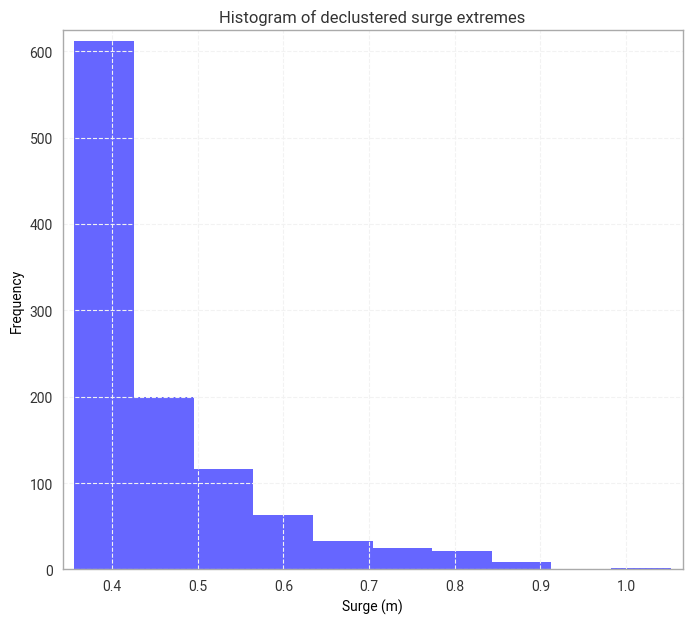

In [19]:
plt.hist(declustered_surge, bins = 10, alpha = 0.6, color = "b")
plt.xlabel("Surge (m)")
plt.ylabel("Frequency")
plt.title("Histogram of declustered surge extremes")

In [20]:
from scipy.stats import genpareto

shape_fit, loc_fit, scale_fit = genpareto.fit(declustered_surge, fc = 0) # fit general pareto distribution 

# NOTE; this fixes the shape parameter, not using it as a first guess. We need to this as an estimate and not a fix.

In [21]:
return_periods = [1, 2, 5, 10, 25, 50, 75, 100]

# Estimated return periods (TODO: convert to table)

rp1 = genpareto.isf(1/1, c = shape_fit, loc=loc_fit, scale=scale_fit)
rp2 = genpareto.isf(1/2, c = shape_fit, loc=loc_fit, scale=scale_fit)
rp5 = genpareto.isf(1/5, c = shape_fit, loc=loc_fit, scale=scale_fit)
rp10 = genpareto.isf(1/10, c = shape_fit, loc=loc_fit, scale=scale_fit)
rp25 = genpareto.isf(1/25, c = shape_fit, loc=loc_fit, scale=scale_fit)
rp50 = genpareto.isf(1/50, c = shape_fit, loc=loc_fit, scale=scale_fit)
rp75 = genpareto.isf(1/75, c = shape_fit, loc=loc_fit, scale=scale_fit)
rp100 = genpareto.isf(1/100, c = shape_fit, loc=loc_fit, scale=scale_fit)


(section-results)=
### 5. Results

#### Results Subsections
Describe what is done in this step/section and what the `code` in the cell does (if code is included). 

If this is the **results section**, we expect the final plots to be created here with a description of how to interpret them, and what information can be extracted for the specific use case and user question. The information in the 'quality assessment statement' should be derived here. 

In [ ]:
# collapsable code cell

# code is included for transparency but also learning purposes and gives users the chance to adapt the code used for the assessment as they wish

## ℹ️ If you want to know more

### Key resources

List some key resources related to this assessment. E.g. CDS entries, applications, dataset documentation, external pages.
Also list any code libraries used (if applicable).

Code libraries used:
* 

### References

List the references used in the Notebook here.

E.g.

[[1]](https://doi.org/10.1038/s41598-018-20628-2) Rodriguez, D., De Voil, P., Hudson, D., Brown, J. N., Hayman, P., Marrou, H., & Meinke, H. (2018). Predicting optimum crop designs using crop models and seasonal climate forecasts. Scientific reports, 8(1), 2231.